<a href="https://colab.research.google.com/github/rltxjftlfgdj5/2026_tues_bigdatacomputong_class/blob/main/%EB%8B%A4%EC%A4%91_%ED%8A%B9%EC%84%B1_%ED%9A%8C%EA%B7%80_%EB%AA%A8%EB%8D%B8_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_%EA%B5%AC%EC%B6%95_%EB%B0%8F_Streamlit_%EC%9B%B9_%EC%84%9C%EB%B9%84%EC%8A%A4_%EB%B0%B0%ED%8F%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 데이터 준비 및 훈련 샘플 추출
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url).dropna()

# 예측에 쓸 특성 3개 (Schooling 제외)
feature_names = ['Adult mortality', 'BMI', 'GDP']
X = df[feature_names].values
y = df['Life expectancy'].values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 과대적합을 보려고 훈련 데이터는 50개만 사용
np.random.seed(42)
idx = np.random.choice(len(X_train_full), 50, replace=False)
X_train = X_train_full[idx]
y_train = y_train_full[idx]

print("훈련:", X_train.shape[0], "/ 테스트:", X_test.shape[0])

훈련: 50 / 테스트: 330


In [ ]:
# 2. 모델 3종 학습 및 저장
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
import joblib

# Linear(1차) / Poly(3차, 규제X) / Ridge(3차, alpha=1.0)
model_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=1)),
    ("regressor", LinearRegression())
])
model_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3)),
    ("regressor", LinearRegression())
])
model_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3)),
    ("regressor", Ridge(alpha=1.0))
])

for m in (model_linear, model_poly, model_ridge):
    m.fit(X_train, y_train)

joblib.dump(model_linear, "model_linear.pkl")
joblib.dump(model_poly, "model_poly.pkl")
joblib.dump(model_ridge, "model_ridge.pkl")

# 슬라이더 범위로 쓸 변수별 min/max/mean 저장
feature_info = {
    "names": feature_names,
    "min": df[feature_names].min().tolist(),
    "max": df[feature_names].max().tolist(),
    "mean": df[feature_names].mean().tolist()
}
joblib.dump(feature_info, "feature_info.pkl")

print("저장 완료")

저장 완료


    Model  Train R2  Test R2  Train MSE  Test MSE  Complexity
0  Linear     0.729    0.570      29.73     30.53           4
1    Poly     0.901   -4.903      10.88    419.25          20
2   Ridge     0.880    0.639      13.18     25.67          20


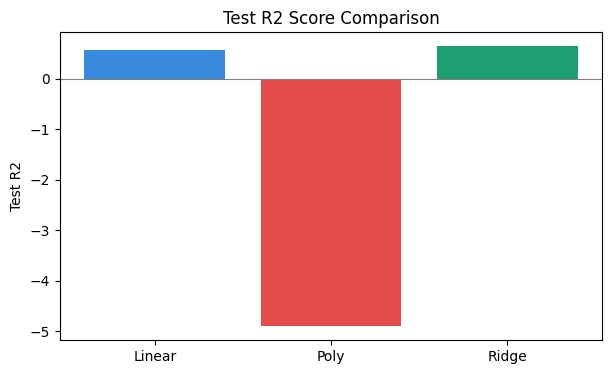

In [ ]:
# 3. 세가지 모델 성능 비교
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

models = {"Linear": model_linear, "Poly": model_poly, "Ridge": model_ridge}

results = []
for name, model in models.items():
    tr = model.predict(X_train)
    te = model.predict(X_test)
    results.append({
        "Model": name,
        "Train R2": round(r2_score(y_train, tr), 3),
        "Test R2": round(r2_score(y_test, te), 3),
        "Train MSE": round(mean_squared_error(y_train, tr), 2),
        "Test MSE": round(mean_squared_error(y_test, te), 2),
        "Complexity": model.named_steps["poly"].n_output_features_
    })

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(7, 4))
plt.bar(results_df["Model"], results_df["Test R2"],
        color=["#378ADD", "#E24B4A", "#1D9E75"])
plt.title("Test R2 Score Comparison")
plt.ylabel("Test R2")
plt.axhline(0, color="gray", linewidth=0.8)
plt.show()

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

st.set_page_config(page_title="기대수명 예측", layout="wide")
st.title("WHO 기대수명 예측 웹 서비스")
st.write("3개 특성으로 기대수명을 예측하고 세 모델의 성능을 비교합니다.")

@st.cache_resource
def load_models():
    ml = joblib.load("model_linear.pkl")
    mp = joblib.load("model_poly.pkl")
    mr = joblib.load("model_ridge.pkl")
    info = joblib.load("feature_info.pkl")
    return ml, mp, mr, info

model_linear, model_poly, model_ridge, feature_info = load_models()
models = {"Linear": model_linear, "Poly": model_poly, "Ridge": model_ridge}
feature_names = feature_info["names"]

# 성능 계산용 데이터
st.header("1. 모델 성능 비교")
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url).dropna()
X = df[feature_names].values
y = df["Life expectancy"].values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
np.random.seed(42)
idx = np.random.choice(len(X_train_full), 50, replace=False)
X_train, y_train = X_train_full[idx], y_train_full[idx]

results = []
for name, model in models.items():
    tr = model.predict(X_train)
    te = model.predict(X_test)
    results.append({
        "Model": name,
        "Train R2": round(r2_score(y_train, tr), 3),
        "Test R2": round(r2_score(y_test, te), 3),
        "Train MSE": round(mean_squared_error(y_train, tr), 2),
        "Test MSE": round(mean_squared_error(y_test, te), 2),
        "Complexity": model.named_steps["poly"].n_output_features_
    })
results_df = pd.DataFrame(results)
st.dataframe(results_df, use_container_width=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results_df["Model"], results_df["Test R2"],
       color=["#378ADD", "#E24B4A", "#1D9E75"])
ax.set_title("Test R2 Score Comparison")
ax.set_ylabel("Test R2")
ax.axhline(0, color="gray", linewidth=0.8)
st.pyplot(fig)

# 사이드바 입력
st.sidebar.header("입력값 조절")
user_inputs = []
for i, name in enumerate(feature_names):
    lo = float(feature_info["min"][i])
    hi = float(feature_info["max"][i])
    mid = float(feature_info["mean"][i])
    user_inputs.append(st.sidebar.slider(name, lo, hi, mid))

selected_name = st.sidebar.selectbox("예측에 사용할 모델", ["Linear", "Poly", "Ridge"])

# 예측 결과
st.header("2. 실시간 예측 결과")
model = models[selected_name]
pred = model.predict(np.array([user_inputs]))[0]
st.metric(label=f"예측 모델: {selected_name}", value=f"{pred:.1f} 세")

st.write("입력한 값")
st.dataframe(pd.DataFrame([user_inputs], columns=feature_names),
             use_container_width=True)

Writing app.py


In [ ]:
# 4. ngrok으로 웹 서비스 배포
!pip install streamlit pyngrok -q

import os
from pyngrok import ngrok

ngrok.kill()  # 기존 터널 정리
ngrok.set_auth_token("토큰입력")  # <- - - - - - - - - - - - - - - - - - < 여기에 토큰 넣기 >
os.system("streamlit run app.py --server.address 127.0.0.1 &")

public_url = ngrok.connect(8501, bind_tls=True)
print("접속 링크:", public_url)

KeyboardInterrupt: 

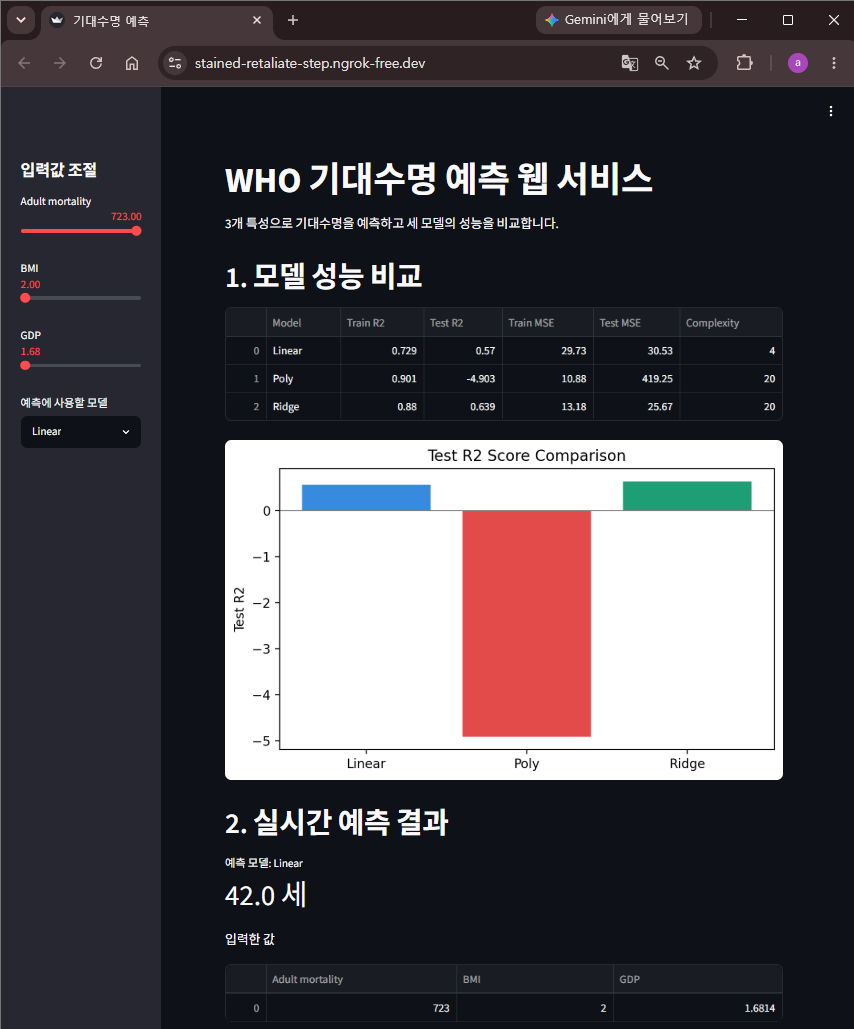

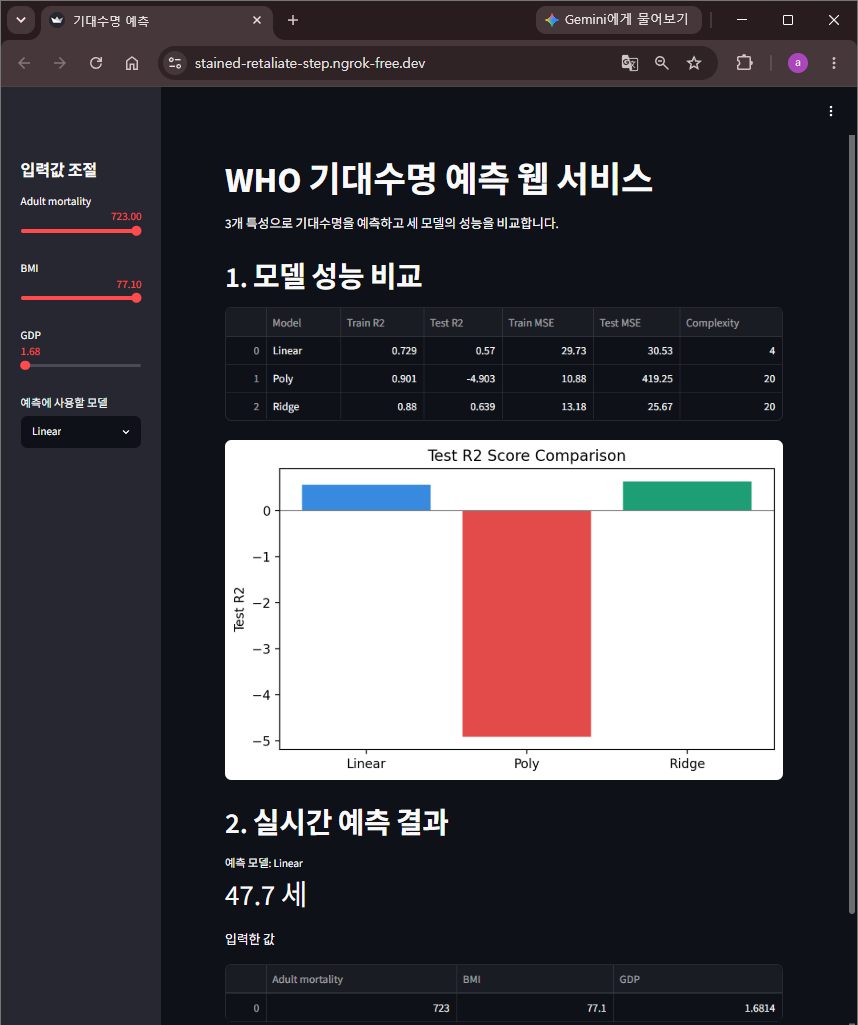

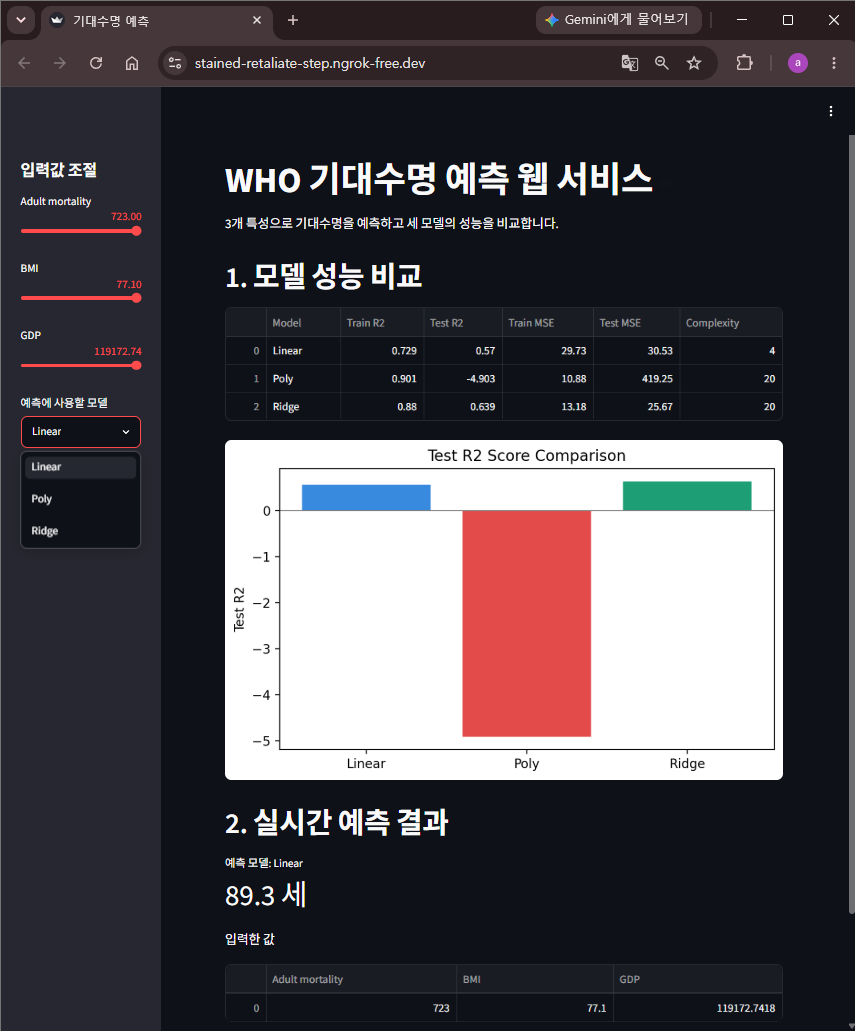

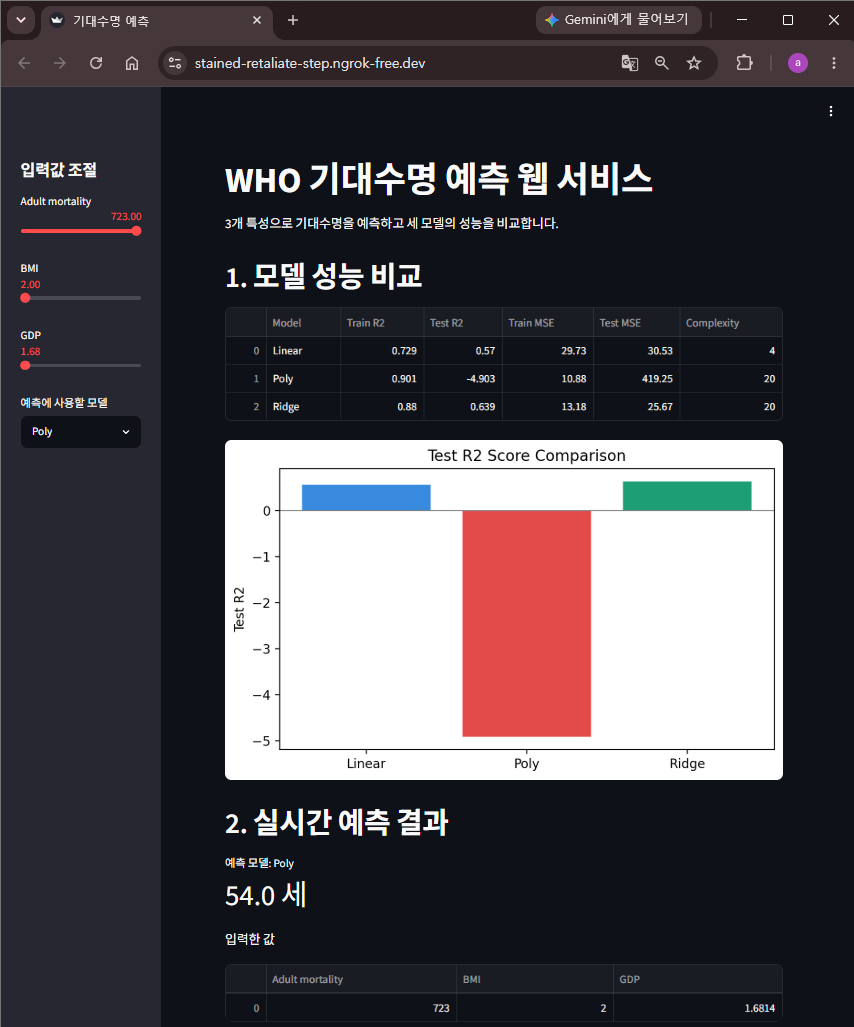

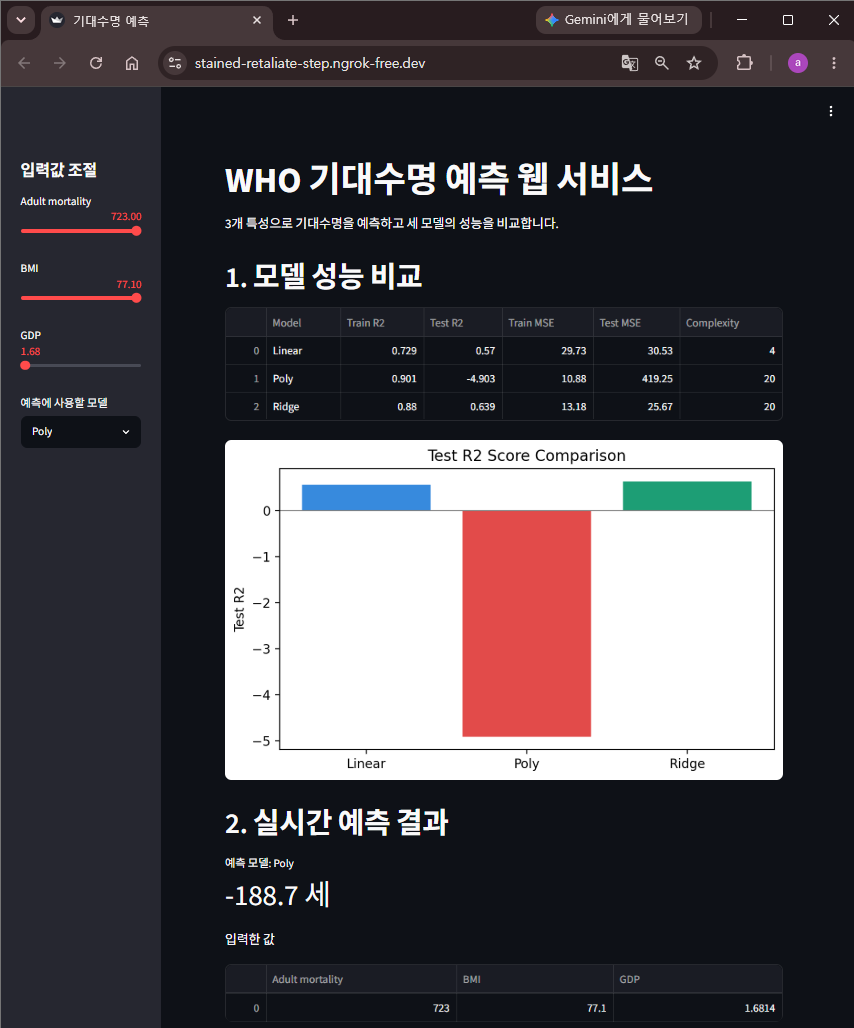

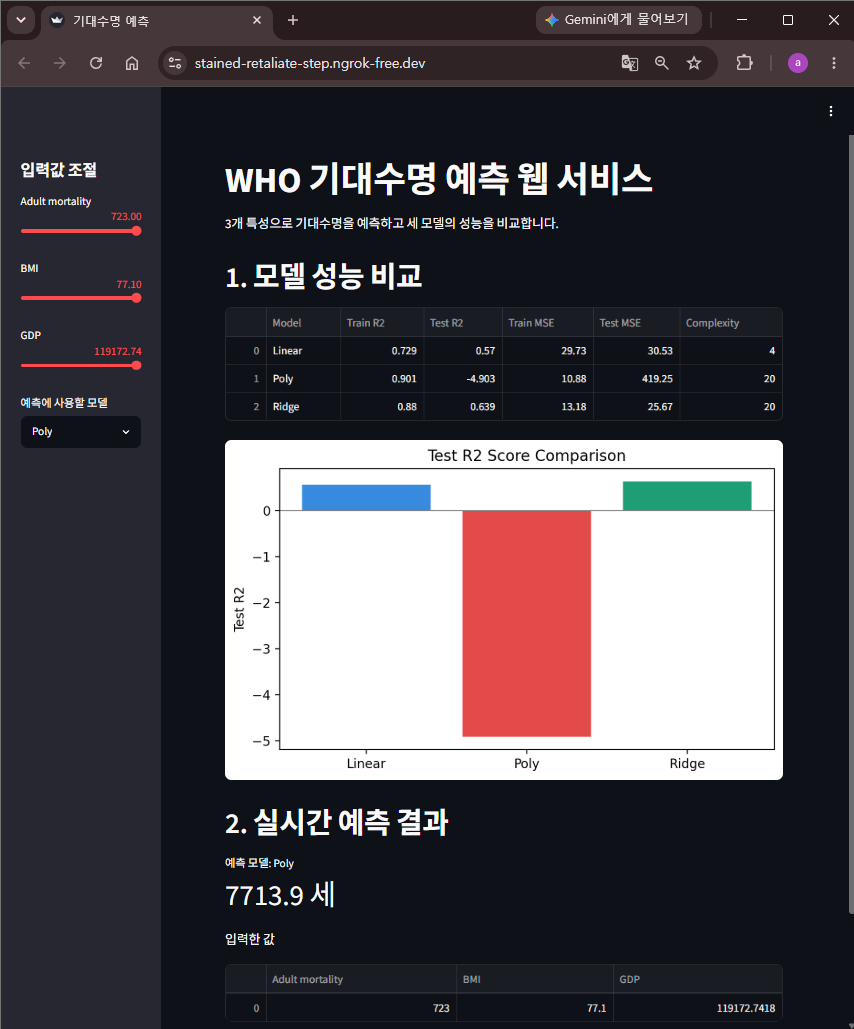

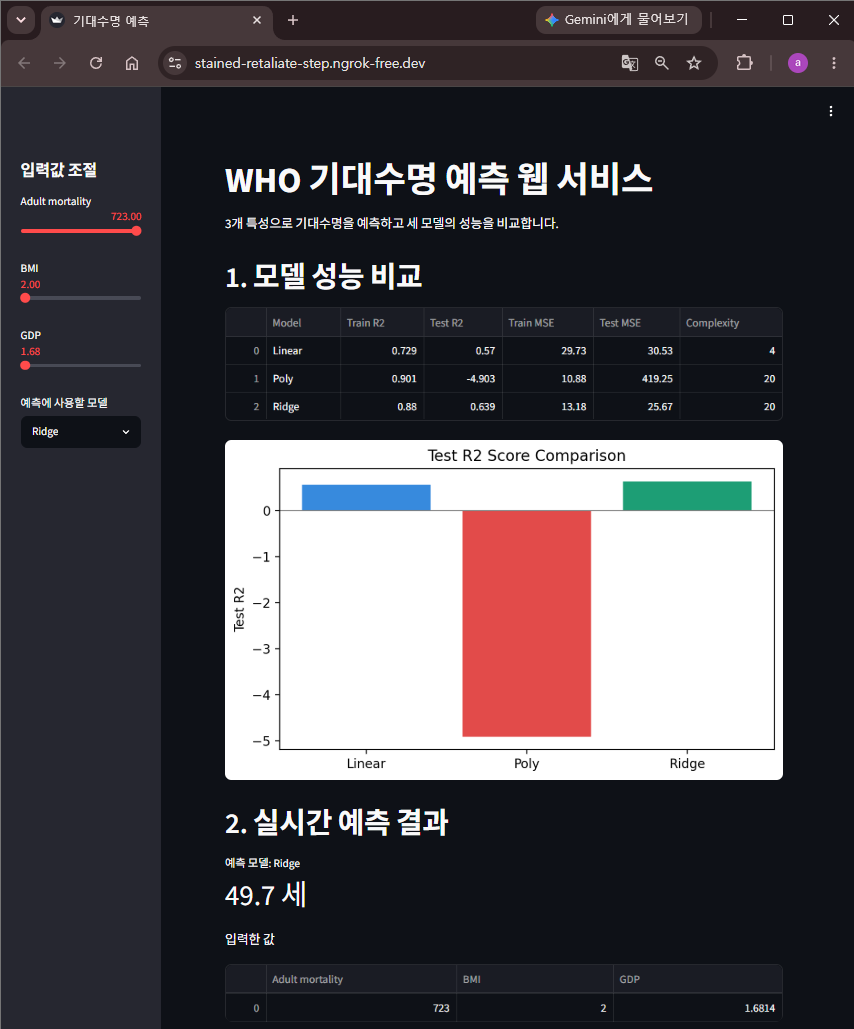

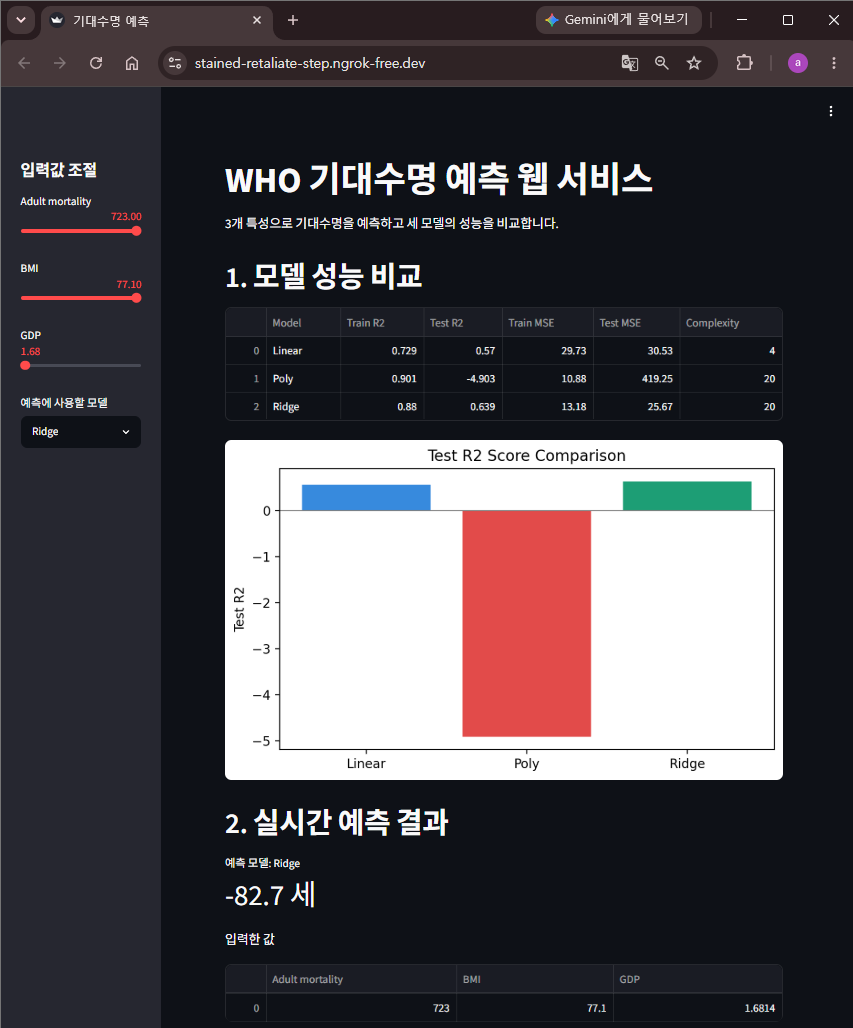

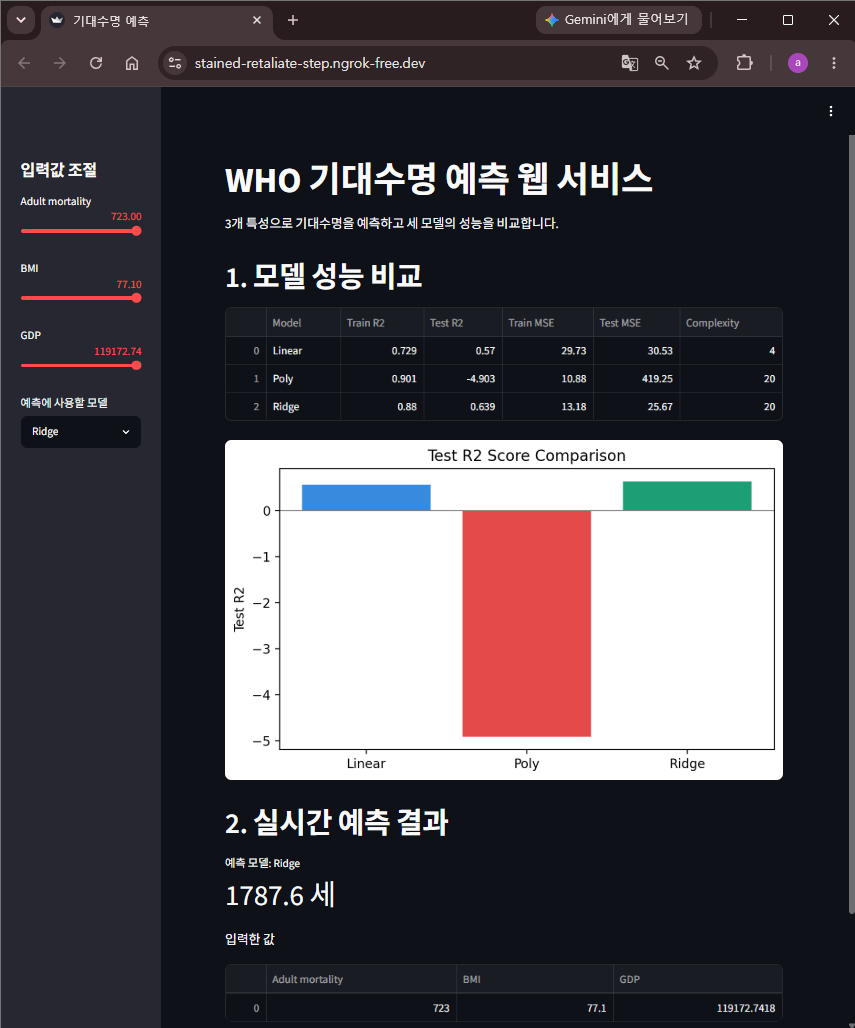

